# Image Quality (QI) Analysis

In this notebook, the ....

# Packages

In [160]:
packages <- list("lme4", "glmmTMB", "ggeffects")
for (pack in packages) {
    if (!requireNamespace(pack, quietly = TRUE)) {
      print(paste('Installing', pack))
      install.packages(pack)
    }
}

In [162]:
library(readr)
library(lme4)
library(glmmTMB)
library(ggplot2)
library(ggeffects)

# Read Dataset

In [150]:
dataset_v0 = read_csv("data/dataset/suited_dataset.csv", show_col_types = FALSE)
dim(dataset_v0)

[1] 1772    9

In [151]:
ds_qi_per_img = read_csv("output/qi_per_img_3.csv", show_col_types = FALSE)
dim(ds_qi_per_img)

[1] 1772    2

In [166]:
dataset_v1 = merge(x = dataset_v0, y = ds_qi_per_img, by='depth')
dim(dataset_v1)

[1] 1772   10

In [167]:
dataset_v1 <- dataset_v1[,-c(1, 5,6)]
head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,gender,qi
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>
1,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3305.927
2,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3338.609
3,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3289.363
4,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3317.456
5,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3379.749
6,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3374.645


In [168]:
dataset_v1$farm  = as.factor(dataset_v1$farm)
dataset_v1$unexpected_behavior = as.factor(dataset_v1$unexpected_behavior)
dataset_v1$animal_id = as.factor(dataset_v1$animal_id)
dataset_v1$gender = as.factor(dataset_v1$gender)

head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,gender,qi
,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<dbl>
1,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3305.927
2,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3338.609
3,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3289.363
4,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3317.456
5,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3379.749
6,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3374.645


# Model Evaluation

....

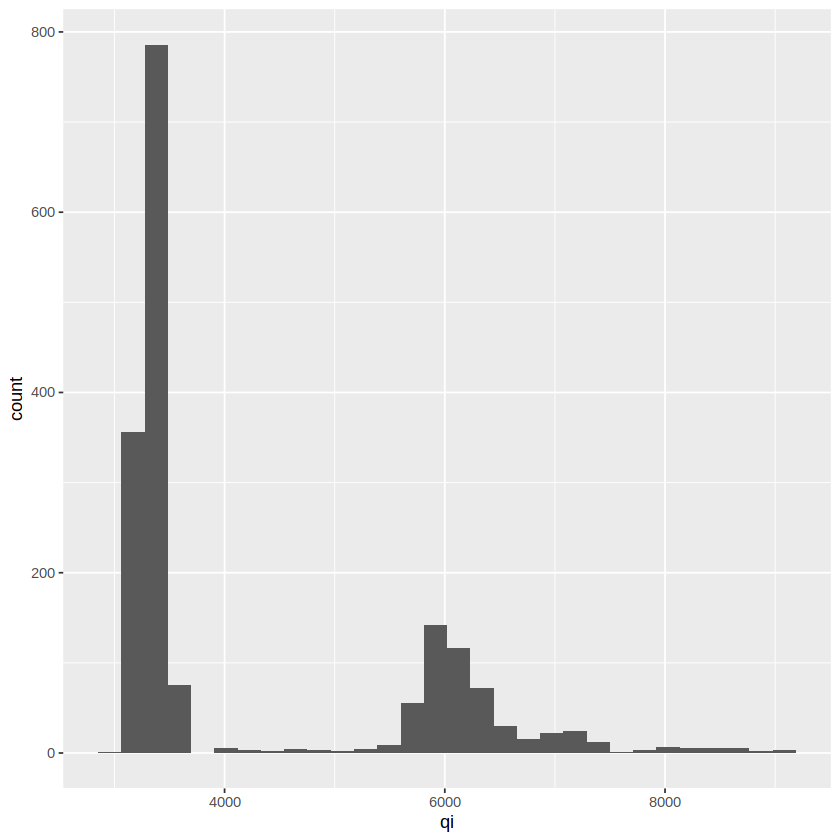

In [102]:
ggplot(dataset_v1, aes(x = qi)) + geom_histogram(bins = 30)

## Adjusting models

In [157]:
model1 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min + weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(model1)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.200536 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23262.3  23300.7 -11624.2  23248.3     1765 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3185 -0.2261 -0.0072  0.2182  6.4874 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001406 0.03750 
 Residual              0.001857 0.04309 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                           Estimate  Std. Error t value            Pr(>|z|)    
(Intercept)              8.27493642  0.02069146 399.920 <0.0000000000000002 ***
farmFarm B              -0.93667785  0.01470697 -63.689 <0.0000000000000002 ***
captured_at_as_min       0.00075759  0.00002044  37.063 <0.0000000000000002 ***
weight                  -0.00069088  0.00042969  -1

In [158]:
model2 <- lme4::glmer(
  'qi ~ farm * captured_at_as_min + weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model2)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.230946 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * captured_at_as_min + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23256.9  23300.7 -11620.5  23240.9     1764 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3280 -0.2225 -0.0048  0.2150  6.4511 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001310 0.03620 
 Residual              0.001831 0.04279 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                 Estimate  Std. Error t value
(Intercept)                    8.21297344  0.01965210 417.918
farmFarm B                     0.85054735  0.02806759  30.304
captured_at_as_min             0.00088060  0.00001895  46.462
weight                        -0.00115307  0.00041622  -2.770
unexpected_behaviorTRUE        0.00816521  0.01424445   0.573

## Effect Analysis

In [143]:
eff1 <- ggpredict(model2, terms = c("captured_at_as_min", "farm"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Capture Time",
    y = "Predicted QI",
    color = "Farm"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

ggsave(
  "output/qi_effect_time_x_farm.png",
  cha1,
  width = 12,
  height = 6,
  dpi = 600,
)

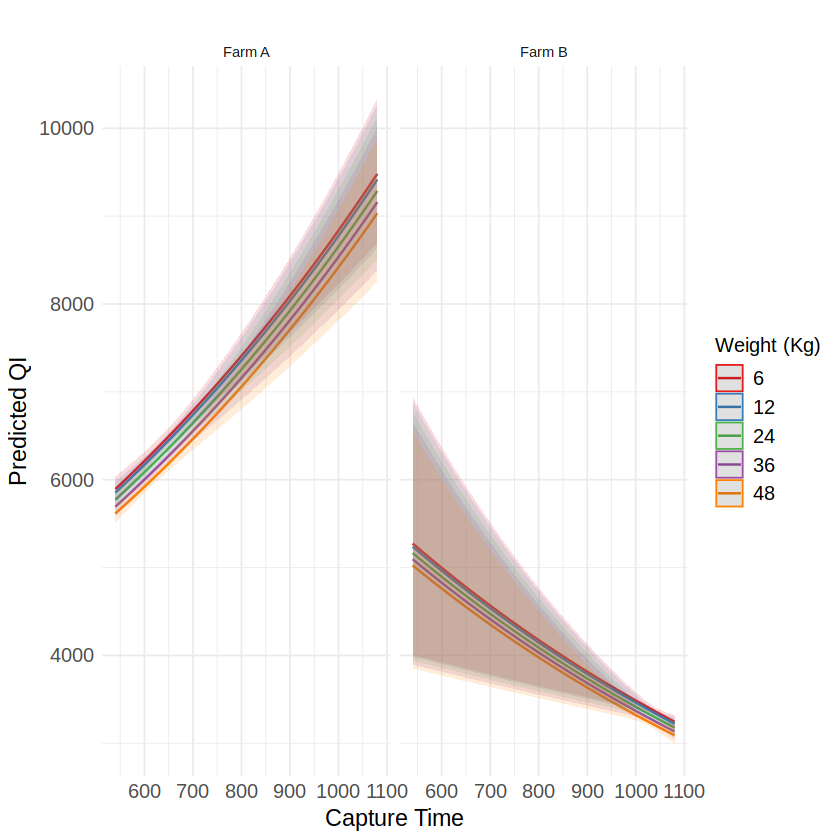

In [169]:
eff2 <- ggpredict(model2, terms = c("captured_at_as_min", "weight [6, 12, 24, 36, 48]", "farm"))
plot(eff_weight) +
  labs(
    title = "",
    x = "Capture Time",
    y = "Predicted QI",
    color = "Weight (Kg)"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 12)
  )